# Stage 6 — three candidate phase-zero landmarks

This notebook starts again from the raw contiguous movement blocks. Its purpose
is deliberately narrow: construct three candidate phase-zero definitions from
a consistent dominant-oscillation clock, then show the resulting events against
real time. We stop after those diagnostics so that the observed event structure
can guide the next question.

The processing order is fixed and explicit:

1. For each block and hand, find the full-block dominant 3-D oscillation axis.
2. Project the root-relative hand trajectory onto that axis and band-pass it.
3. Use its Hilbert phase to segment complete cycles.
4. Fit the package's local PCA model separately inside each phase cycle.
5. Pair overlapping left/right cycles and estimate the three landmarks below.

This removes the earlier mismatch in which cycles came from hand Y but the
diagnostic displayed a different dominant-axis signal. The local PCA results are
calculated here, but geometry and reconstructed-cycle plots are intentionally
deferred until the timing displays have been inspected.

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.signal import butter, sosfiltfilt

WORKING_DIR = Path.cwd()
NB_DIR = next((candidate for candidate in (
    WORKING_DIR, WORKING_DIR / "notebooks" / "gorilla_tag_analysis"
) if (candidate / "_loading.py").exists()), None)
if NB_DIR is None:
    raise FileNotFoundError("Run this notebook from its directory or the repository root.")
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import _loading as L
import _plotting as P
from phase_coordinates import estimate_dominant_period, fit_pca_phase_coordinates

SUBJECT = "002"
HANDS = ("l_hand", "r_hand")
PHASE_MARGIN = 0.10
N_PHASE_GRID = 72
MIN_MATCHED_CYCLES = 4
PHASE_GRID = np.linspace(PHASE_MARGIN, 2 * np.pi - PHASE_MARGIN, N_PHASE_GRID)

METHOD_COLORS = {
    "peak": "#4D4D4D",
    "simultaneous": "#0072B2",
    "fixed_relative": "#009E73",
}
METHOD_LABELS = {
    "peak": "Peak of band-passed Y-oriented signal",
    "simultaneous": "Minimum zero-lag error",
    "fixed_relative": "Minimum fixed-lag variability",
}
HAND_MARKERS = {"l_hand": "o", "r_hand": "^"}
RUNS = L.list_available_blocks(subject=SUBJECT)
print(f"{len(RUNS)} contiguous blocks; {2 * len(RUNS)} hand fits will be recalculated.")

58 contiguous blocks; 116 hand fits will be recalculated.


## What the three definitions mean

The dominant axis has an arbitrary sign. We orient it to have a non-negative Y
component, so a **peak** is consistently the positive-Y end of that axis. The
peak landmark is the maximum of the filtered dominant score within each complete
cycle; it may move slightly in phase from cycle to cycle.

For the other definitions, let `t_left,k(q_left)` and
`t_right,k(q_right)` be the real times at which paired cycle `k` reaches the two
candidate phases, and define

`d_k(q_left, q_right) = t_right,k(q_right) - t_left,k(q_left)`.

The two fitted definitions are:

- **Minimum variability about simultaneity:** minimize `mean(d_k**2)`. This is
  the RMS event-time difference about a fixed target of zero, so it penalizes
  both cycle-to-cycle variation and a systematic left/right lag.
- **Minimum variability about a fixed relative difference:** first fit the
  block's fixed lag `delta = mean(d_k)`, then minimize
  `mean((d_k - delta)**2)`. This rewards repeatability while allowing one hand
  to lead consistently.

These timing criteria estimate a pair of hand-specific phase locations. They are
not, by themselves, proof of a biologically privileged absolute origin. The
real-time plots below are the first check of whether they identify coherent,
recognizable events.

## Recalculate dominant-reference cycles and local PCA

No Stage 2 PCA cache is read. The helpers below load each raw block, invoke the
automatic dominant-reference path on this branch, retain only complete monotonic
phase cycles for inverse timing maps, and pair mutually nearest overlapping
left/right cycles. The filtered signal reconstructed here uses exactly the same
automatically selected band as the phase estimator. Exact phase-boundary times
are interpolated from their bracketing samples, so a valid cycle is not discarded
merely because no sample lands inside the phase-grid margin.

In [6]:
FILE_CACHE = {}
KEY_COLUMNS = ("subject", "day", "part", "skill", "source_file", "movement_run_id")


def block_key(row):
    return tuple(getattr(row, name) for name in KEY_COLUMNS)


def load_hand_from_row(row, hand):
    position = L.load_position_file(row.path, FILE_CACHE)
    segment = position.iloc[int(row.run_start):int(row.run_end)]
    hand_cols = [f"{hand}.x", f"{hand}.y", f"{hand}.z"]
    root_cols = ["root.x", "root.y", "root.z"]
    return (segment[hand_cols].to_numpy(float)
            - segment[root_cols].to_numpy(float))


def fit_hand(row, hand):
    X = load_hand_from_row(row, hand)
    samples, cycles, details = fit_pca_phase_coordinates(
        X, sampling_rate_hz=L.FS_HZ
    )

    # Reconstruct the same automatic band used inside the fitter.
    reference_raw = np.asarray(details["ref_signal"], dtype=float)
    dominant_period = estimate_dominant_period(reference_raw, L.FS_HZ)
    band = (0.5 / dominant_period, 2.0 / dominant_period)
    sos = butter(4, band, btype="bandpass", fs=L.FS_HZ, output="sos")
    reference_filtered = sosfiltfilt(sos, reference_raw)

    # Recover and Y-orient the full-block dominant axis for interpretation.
    centered = X - X.mean(axis=0)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    sign = -1.0 if vt[0, 1] < 0 else 1.0
    axis = sign * vt[0]
    reference_raw = sign * reference_raw
    reference_filtered = sign * reference_filtered

    return {
        "X": X, "samples": samples, "cycles": cycles, "details": details,
        "reference_raw": reference_raw,
        "reference_filtered": reference_filtered,
        "dominant_axis": axis, "dominant_period": dominant_period,
        "band": band,
    }


def complete_cycle_maps(fit, phase_grid=PHASE_GRID):
    rows = []
    samples = fit["samples"]
    filtered = fit["reference_filtered"]
    phase0 = samples["phase"].to_numpy(float) - float(samples["phase"].iloc[0])
    all_times = samples["time"].to_numpy(float)
    for cycle, group in samples.groupby("cycle", sort=True):
        sample_index = group["sample_index"].to_numpy(int)
        if len(sample_index) < 3:
            continue

        # Include one sample on each side of the phase bin. Those samples
        # bracket the exact 0 and 2*pi boundaries even when the first/last
        # in-bin samples lie farther from them than PHASE_MARGIN.
        bridge_index = np.arange(
            max(0, sample_index[0] - 1),
            min(len(samples) - 1, sample_index[-1] + 1) + 1,
        )
        phase_bridge = phase0[bridge_index]
        time_bridge = all_times[bridge_index]
        valid = np.isfinite(phase_bridge) & np.isfinite(time_bridge)
        phase_bridge, time_bridge = phase_bridge[valid], time_bridge[valid]
        if len(phase_bridge) < 3 or np.any(np.diff(phase_bridge) <= 0):
            continue

        boundaries = 2 * np.pi * (int(cycle) + np.array([0.0, 1.0]))
        if boundaries[0] < phase_bridge[0] or boundaries[-1] > phase_bridge[-1]:
            continue
        boundary_times = np.interp(boundaries, phase_bridge, time_bridge)
        target_phase = 2 * np.pi * int(cycle) + phase_grid
        peak_sample = sample_index[np.argmax(filtered[sample_index])]
        rows.append({
            "cycle": int(cycle),
            "start": float(boundary_times[0]), "stop": float(boundary_times[1]),
            "mid": float(boundary_times.mean()),
            "q": phase_bridge - 2 * np.pi * int(cycle), "t": time_bridge,
            "t_at_q": np.interp(target_phase, phase_bridge, time_bridge),
            "peak_time": float(samples.loc[peak_sample, "time"]),
            "peak_q": float(samples.loc[peak_sample, "phase_in_cycle"]),
        })
    return rows


def pair_cycles(left_cycles, right_cycles):
    if not left_cycles or not right_cycles:
        return []
    left_mid = np.array([cycle["mid"] for cycle in left_cycles])
    right_mid = np.array([cycle["mid"] for cycle in right_cycles])
    distance = np.abs(left_mid[:, None] - right_mid[None, :])
    nearest_right = distance.argmin(axis=1)
    nearest_left = distance.argmin(axis=0)
    pairs = []
    for left_i, right_i in enumerate(nearest_right):
        if nearest_left[right_i] != left_i:
            continue
        left, right = left_cycles[left_i], right_cycles[right_i]
        if min(left["stop"], right["stop"]) > max(left["start"], right["start"]):
            pairs.append((left, right))
    return pairs


def timing_surfaces(pairs):
    left_t = np.stack([left["t_at_q"] for left, _ in pairs])
    right_t = np.stack([right["t_at_q"] for _, right in pairs])
    differences = right_t[:, None, :] - left_t[:, :, None]
    mean_difference = differences.mean(axis=0)
    zero_lag_mse = np.mean(differences ** 2, axis=0)
    fixed_lag_variance = np.mean(
        (differences - mean_difference) ** 2, axis=0
    )
    return differences, mean_difference, zero_lag_mse, fixed_lag_variance


def surface_minimum(surface):
    return tuple(int(value) for value in np.unravel_index(np.nanargmin(surface), surface.shape))


def analyse_block(hand_fits):
    cycles = {hand: complete_cycle_maps(hand_fits[hand]) for hand in HANDS}
    pairs = pair_cycles(cycles["l_hand"], cycles["r_hand"])
    result = {"cycles": cycles, "pairs": pairs, "fit_ok": False}
    if len(pairs) < MIN_MATCHED_CYCLES:
        result["reason"] = f"only {len(pairs)} matched complete cycles"
        return result

    differences, mean_difference, zero_mse, fixed_variance = timing_surfaces(pairs)
    sim_i, sim_j = surface_minimum(zero_mse)
    fixed_i, fixed_j = surface_minimum(fixed_variance)
    peak_lags = np.array([right["peak_time"] - left["peak_time"] for left, right in pairs])
    sim_lags = differences[:, sim_i, sim_j]
    fixed_lags = differences[:, fixed_i, fixed_j]

    result.update({
        "fit_ok": True, "reason": "",
        "differences": differences, "mean_difference": mean_difference,
        "zero_lag_mse": zero_mse, "fixed_lag_variance": fixed_variance,
        "methods": {
            "peak": {"lags": peak_lags},
            "simultaneous": {
                "q_left": PHASE_GRID[sim_i], "q_right": PHASE_GRID[sim_j],
                "lags": sim_lags,
            },
            "fixed_relative": {
                "q_left": PHASE_GRID[fixed_i], "q_right": PHASE_GRID[fixed_j],
                "lags": fixed_lags, "delta": float(fixed_lags.mean()),
            },
        },
    })
    return result


def event_times(cycles, method, hand, analysis):
    if method == "peak":
        return np.array([cycle["peak_time"] for cycle in cycles])
    q = analysis["methods"][method]["q_left" if hand == "l_hand" else "q_right"]
    return np.array([np.interp(q, cycle["q"], cycle["t"]) for cycle in cycles])

In [7]:
FITS = {}
ANALYSES = {}
summary_rows = []

for row in RUNS.itertuples(index=False):
    key = block_key(row)
    base = {name: getattr(row, name) for name in KEY_COLUMNS}
    base["run_duration_sec"] = float(row.run_duration_sec)
    try:
        hand_fits = {hand: fit_hand(row, hand) for hand in HANDS}
        analysis = analyse_block(hand_fits)
        FITS[key] = hand_fits
        ANALYSES[key] = analysis
    except Exception as exc:
        summary_rows.append({
            **base, "fit_ok": False, "reason": f"{type(exc).__name__}: {exc}",
            "n_left_cycles": np.nan, "n_right_cycles": np.nan, "n_pairs": 0,
        })
        continue

    summary = {
        **base, "fit_ok": analysis["fit_ok"], "reason": analysis["reason"],
        "n_left_cycles": len(analysis["cycles"]["l_hand"]),
        "n_right_cycles": len(analysis["cycles"]["r_hand"]),
        "n_pairs": len(analysis["pairs"]),
    }
    if analysis["fit_ok"]:
        peak = analysis["methods"]["peak"]["lags"]
        simultaneous = analysis["methods"]["simultaneous"]
        fixed = analysis["methods"]["fixed_relative"]
        summary.update({
            "peak_mean_lag_ms": 1000 * peak.mean(),
            "peak_lag_sd_ms": 1000 * peak.std(ddof=1),
            "sim_q_left_rad": simultaneous["q_left"],
            "sim_q_right_rad": simultaneous["q_right"],
            "sim_mean_lag_ms": 1000 * simultaneous["lags"].mean(),
            "sim_rms_lag_ms": 1000 * np.sqrt(np.mean(simultaneous["lags"] ** 2)),
            "fixed_q_left_rad": fixed["q_left"],
            "fixed_q_right_rad": fixed["q_right"],
            "fixed_mean_lag_ms": 1000 * fixed["delta"],
            "fixed_lag_sd_ms": 1000 * fixed["lags"].std(ddof=1),
        })
    summary_rows.append(summary)

block_summary = pd.DataFrame(summary_rows).sort_values(
    ["skill", "day", "part", "source_file", "movement_run_id"]
).reset_index(drop=True)

usable = block_summary[block_summary.fit_ok].copy()
overview = usable.groupby(["skill", "day", "part"]).agg(
    usable_blocks=("fit_ok", "size"),
    median_pairs=("n_pairs", "median"),
    peak_lag_sd_ms=("peak_lag_sd_ms", "median"),
    simultaneous_rms_ms=("sim_rms_lag_ms", "median"),
    fixed_relative_sd_ms=("fixed_lag_sd_ms", "median"),
).round(1)

print(f"Recalculated {len(FITS)} blocks × 2 hands from raw trajectories.")
print(f"{len(usable)} blocks meet the {MIN_MATCHED_CYCLES}-pair minimum; "
      f"{len(block_summary) - len(usable)} are excluded from fitted landmarks.")
display(overview)
if (~block_summary.fit_ok).any():
    display(block_summary.loc[~block_summary.fit_ok, [
        "skill", "day", "movement_run_id", "run_duration_sec",
        "n_left_cycles", "n_right_cycles", "n_pairs", "reason"
    ]])

Recalculated 58 blocks × 2 hands from raw trajectories.
53 blocks meet the 4-pair minimum; 5 are excluded from fitted landmarks.


usable_blocks  median_pairs  peak_lag_sd_ms  \
skill day part                                                
climb 1   s                 8           8.5           115.9   
      3   e                 6          33.5            14.5   
jump  1   s                13           6.0            60.0   
      3   e                 6          28.5            18.4   
walk  1   s                10           8.0            47.1   
      3   e                10          17.5            27.4   

                simultaneous_rms_ms  fixed_relative_sd_ms  
skill day part                                             
climb 1   s                    30.8                  28.8  
      3   e                    12.3                  11.8  
jump  1   s                    58.9                  28.3  
      3   e                    14.2                  13.6  
walk  1   s                    41.1                  31.0  
      3   e                    25.5                  24.9

,skill,day,movement_run_id,run_duration_sec,n_left_cycles,n_right_cycles,n_pairs,reason
2,climb,1,3,5.983333,1,5,1,only 1 matched complete cycles
7,climb,1,8,5.983333,1,4,1,only 1 matched complete cycles
8,climb,1,9,3.983333,1,2,1,only 1 matched complete cycles
32,jump,3,3,18.983333,23,0,0,only 0 matched complete cycles
40,walk,1,4,3.983333,3,3,3,only 3 matched complete cycles


## What each definition discovers in real time

The longest usable block in each skill/day condition is shown from the start of
the block in seconds. First, hand-specific panels compare the observed raw
Y-oriented dominant score with the band-passed signal used for Hilbert phase and
peak finding. Raw is the dark hand-colored trace; band-pass is light gray and
drawn on top so departures from the observed signal remain visible. The marker tracks are connected to the raw signal
so the three definitions can be judged against the observed movement.

The following combined-hand panels deliberately show **only the raw signals**.
The band-passed traces are omitted there so they cannot be mistaken for data.

Six horizontal tracks keep coincident markers visible. From top to bottom they
are peak-left, peak-right, simultaneous-left, simultaneous-right,
fixed-relative-left, and fixed-relative-right. Each method is applied to every
complete monotonic cycle for that hand. Exact cycle boundaries are interpolated
from bracketing samples; only partial edge cycles and cycles with a genuinely
non-monotonic inverse phase map intentionally have no marker. The fitted
timing criteria use only the mutually paired subset, whose size is printed in
each panel.

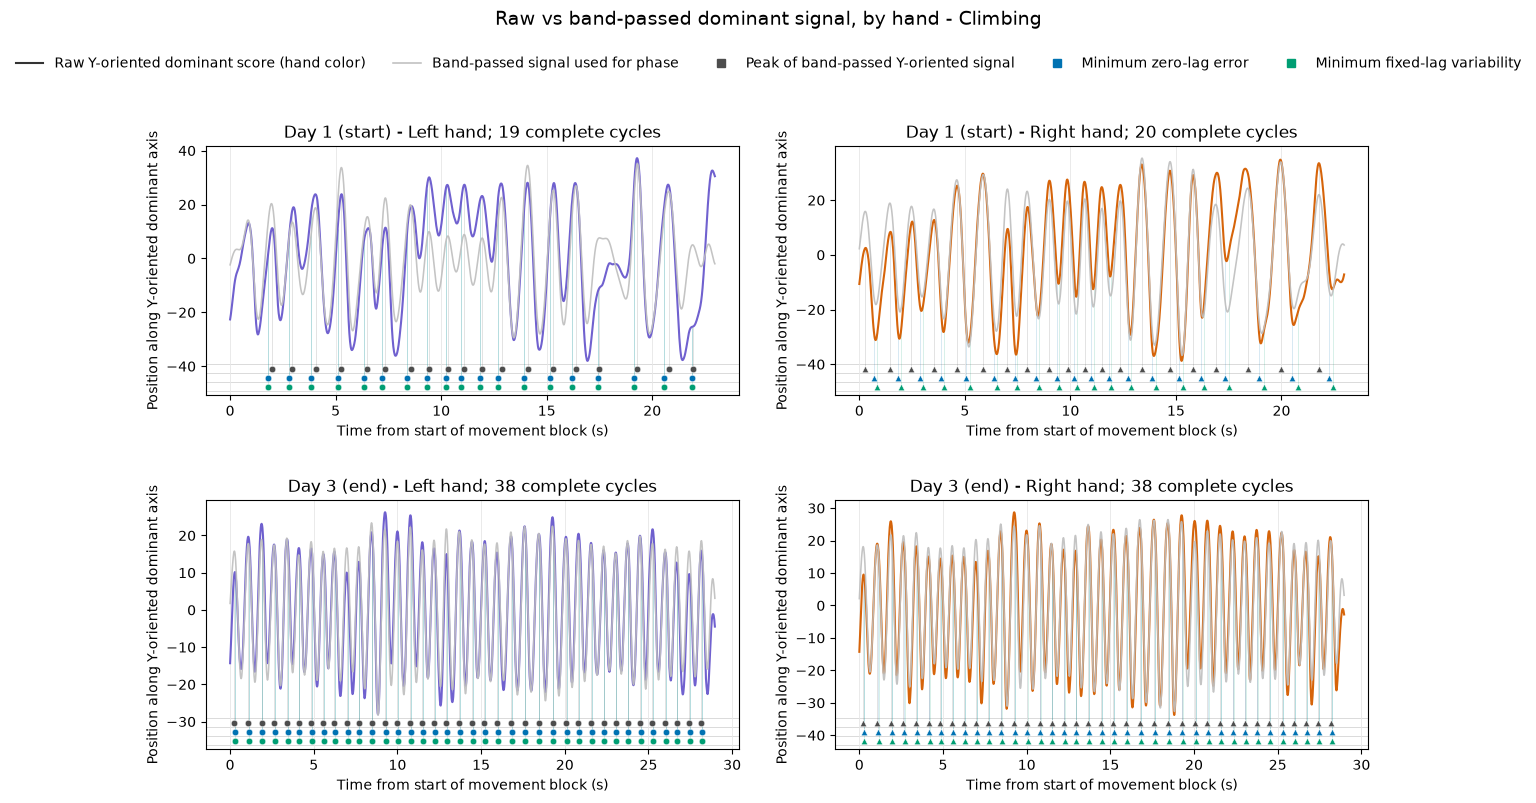

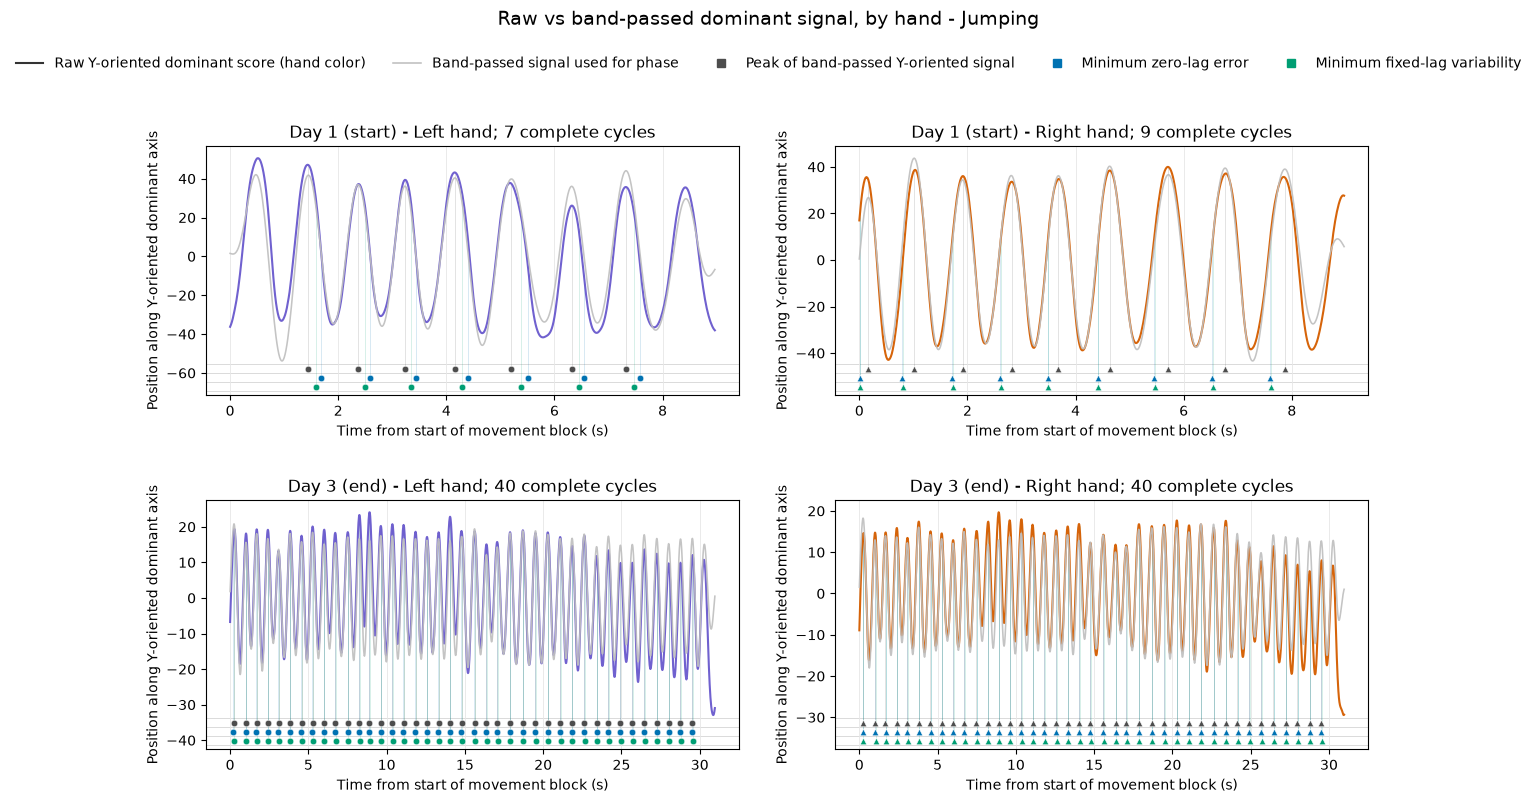

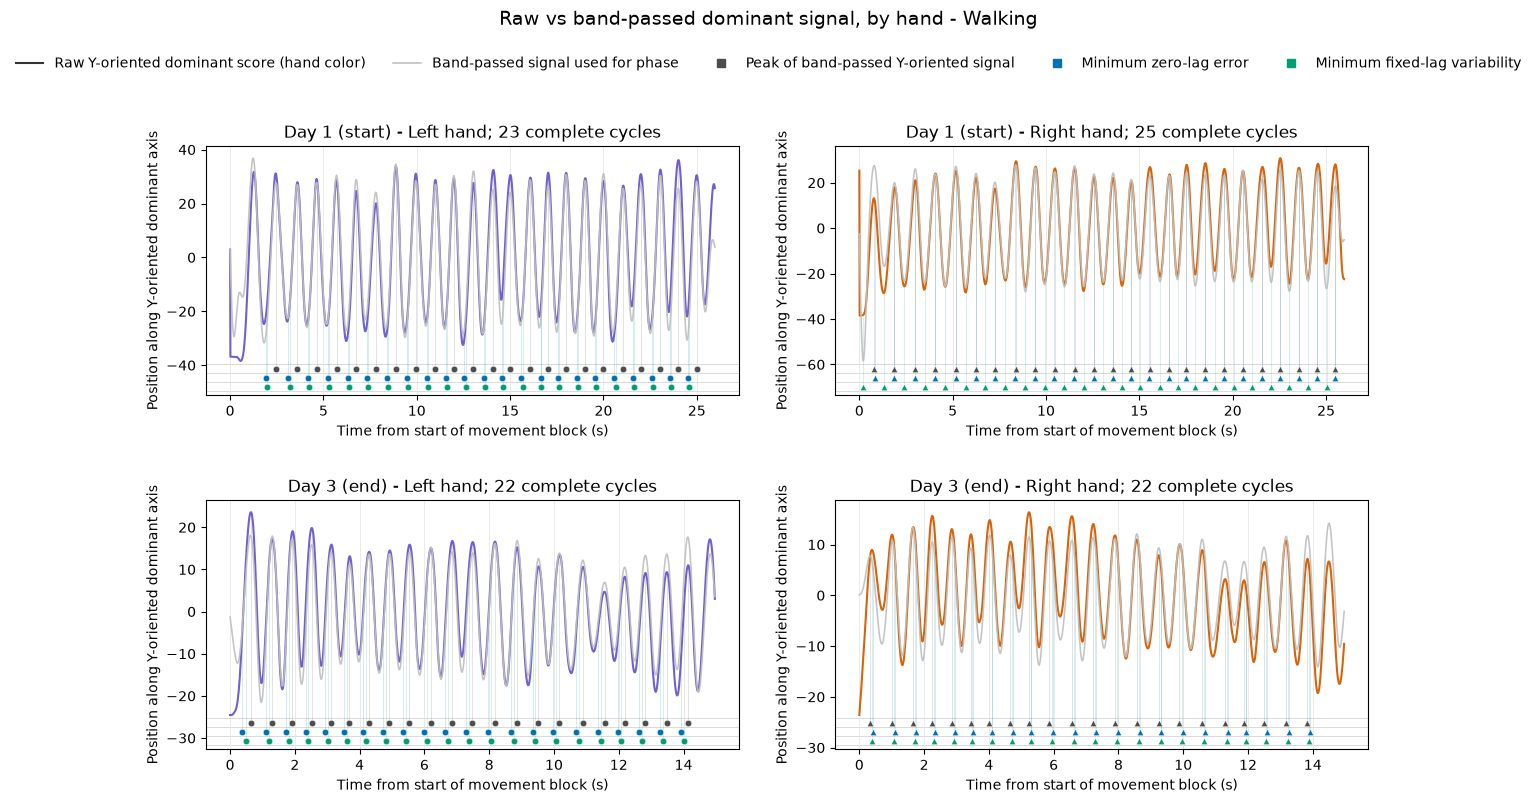

In [8]:
def add_single_hand_event_tracks(ax, time, raw, cycles, hand, analysis, data_low, data_high):
    data_span = max(data_high - data_low, 1.0)
    top_rule = data_low - 0.015 * data_span
    rule_step = 0.045 * data_span
    rules = top_rule - rule_step * np.arange(4)
    track_y = (rules[:-1] + rules[1:]) / 2
    for rule in rules:
        ax.axhline(rule, color="0.82", lw=0.55, zorder=0)
    for y, method in zip(track_y, METHOD_COLORS):
        times = event_times(cycles, method, hand, analysis)
        raw_at_event = np.interp(times, time, raw)
        ax.vlines(
            times, y, raw_at_event, color=METHOD_COLORS[method],
            lw=0.55, alpha=0.20, zorder=1,
        )
        ax.scatter(
            times, np.full(len(times), y), s=22, marker=HAND_MARKERS[hand],
            color=METHOD_COLORS[method], edgecolor="white", linewidth=0.35, zorder=5,
        )
    ax.set_ylim(rules[-1] - 0.02 * data_span, data_high + 0.06 * data_span)


comparison_usable = block_summary[block_summary.fit_ok].copy()
comparison_indices = comparison_usable.groupby(["skill", "day"])["run_duration_sec"].idxmax()
comparison_representatives = comparison_usable.loc[comparison_indices].sort_values(
    ["skill", "day"]
).reset_index(drop=True)

comparison_signal_handles = [
    Line2D([0], [0], color="0.20", lw=1.5, label="Raw Y-oriented dominant score (hand color)"),
    Line2D([0], [0], color="0.75", lw=1.15, label="Band-passed signal used for phase"),
]
comparison_method_handles = [
    Line2D([0], [0], marker="s", ls="none", color=color, label=METHOD_LABELS[method])
    for method, color in METHOD_COLORS.items()
]

for skill in ("climb", "jump", "walk"):
    selected = comparison_representatives[comparison_representatives.skill == skill].sort_values("day")
    fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
    for row_i, row in enumerate(selected.itertuples(index=False)):
        key = tuple(getattr(row, name) for name in KEY_COLUMNS)
        analysis = ANALYSES[key]
        for col_i, hand in enumerate(HANDS):
            ax = axes[row_i, col_i]
            fit = FITS[key][hand]
            time = fit["samples"]["time"].to_numpy(float)
            raw = fit["reference_raw"]
            filtered = fit["reference_filtered"]
            ax.plot(time, raw, color=P.HAND_COLORS[hand], lw=1.5, alpha=0.96, zorder=2)
            ax.plot(time, filtered, color="0.75", lw=1.15, alpha=0.92, zorder=3)
            finite = np.concatenate([raw, filtered])
            finite = finite[np.isfinite(finite)]
            data_low, data_high = float(finite.min()), float(finite.max())
            add_single_hand_event_tracks(
                ax, time, raw, analysis["cycles"][hand], hand, analysis,
                data_low, data_high,
            )
            ax.set_title(
                f"{P.DAY_LABELS[int(row.day)]} ({P.PART_LABELS[row.part]}) - "
                f"{P.HAND_LABELS[hand]}; {len(analysis['cycles'][hand])} complete cycles"
            )
            ax.set_ylabel("Position along Y-oriented dominant axis")
            ax.set_xlabel("Time from start of movement block (s)")
            ax.grid(axis="x", color="0.9", lw=0.6)
    fig.subplots_adjust(top=0.82, hspace=0.42, wspace=0.18)
    fig.suptitle(
        f"Raw vs band-passed dominant signal, by hand - {P.SKILL_LABELS[skill]}",
        fontsize=14, y=0.98,
    )
    fig.legend(
        handles=comparison_signal_handles + comparison_method_handles,
        loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 0.94),
    )
    P.save_figure(fig, f"stage6_{skill}_raw_vs_bandpass_events_by_hand")
    plt.show()

,skill,day,part,movement_run_id,run_duration_sec,n_left_cycles,n_right_cycles,n_pairs,peak_lag_sd_ms,sim_rms_lag_ms,fixed_mean_lag_ms,fixed_lag_sd_ms
0,climb,1,s,6,23.0,19,20,19,170.6,113.1,174.3,108.8
1,climb,3,e,5,29.0,38,38,38,14.3,12.2,21.9,12.2
2,jump,1,s,1,9.0,7,9,6,40.8,26.5,123.8,25.3
3,jump,3,e,5,31.0,40,40,40,15.1,12.5,-13.7,12.2
4,walk,1,s,1,26.0,23,25,22,206.6,203.4,-568.3,200.5
5,walk,3,e,9,15.0,22,22,22,21.2,19.2,-118.7,17.3


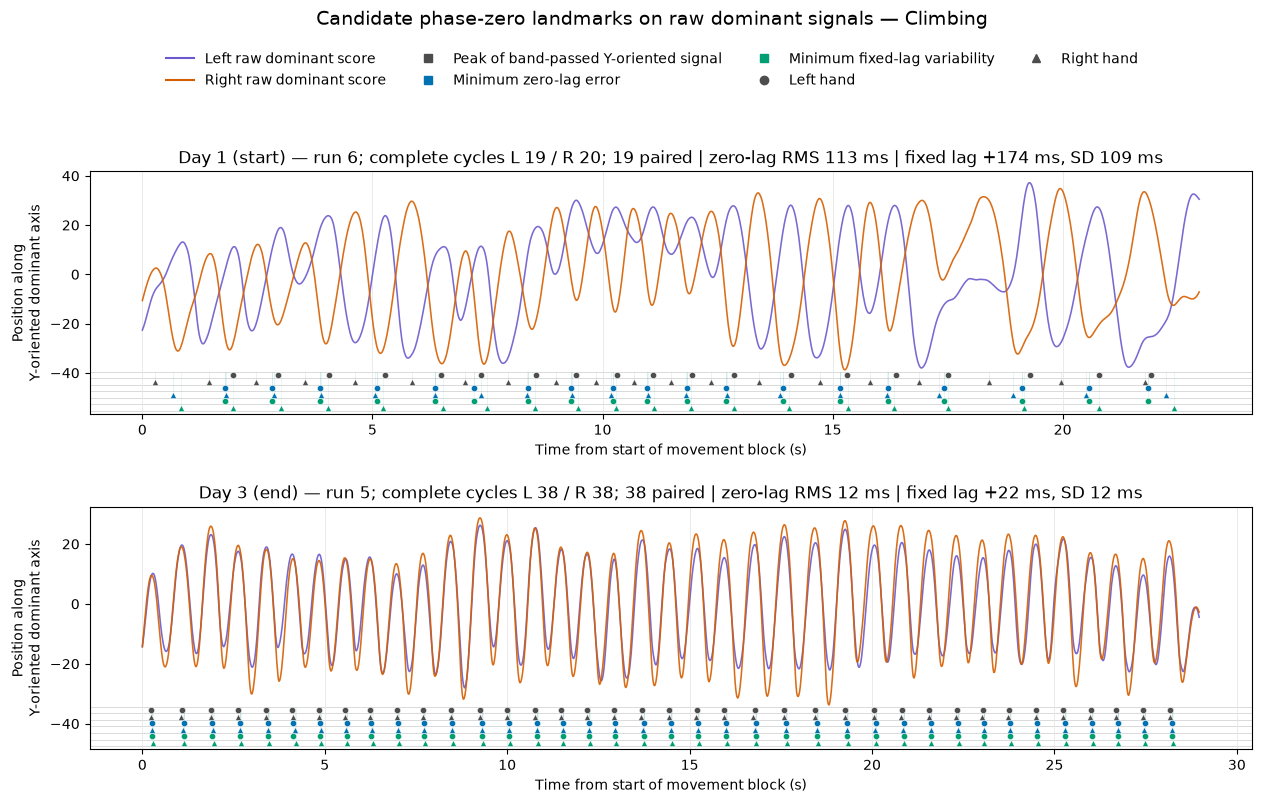

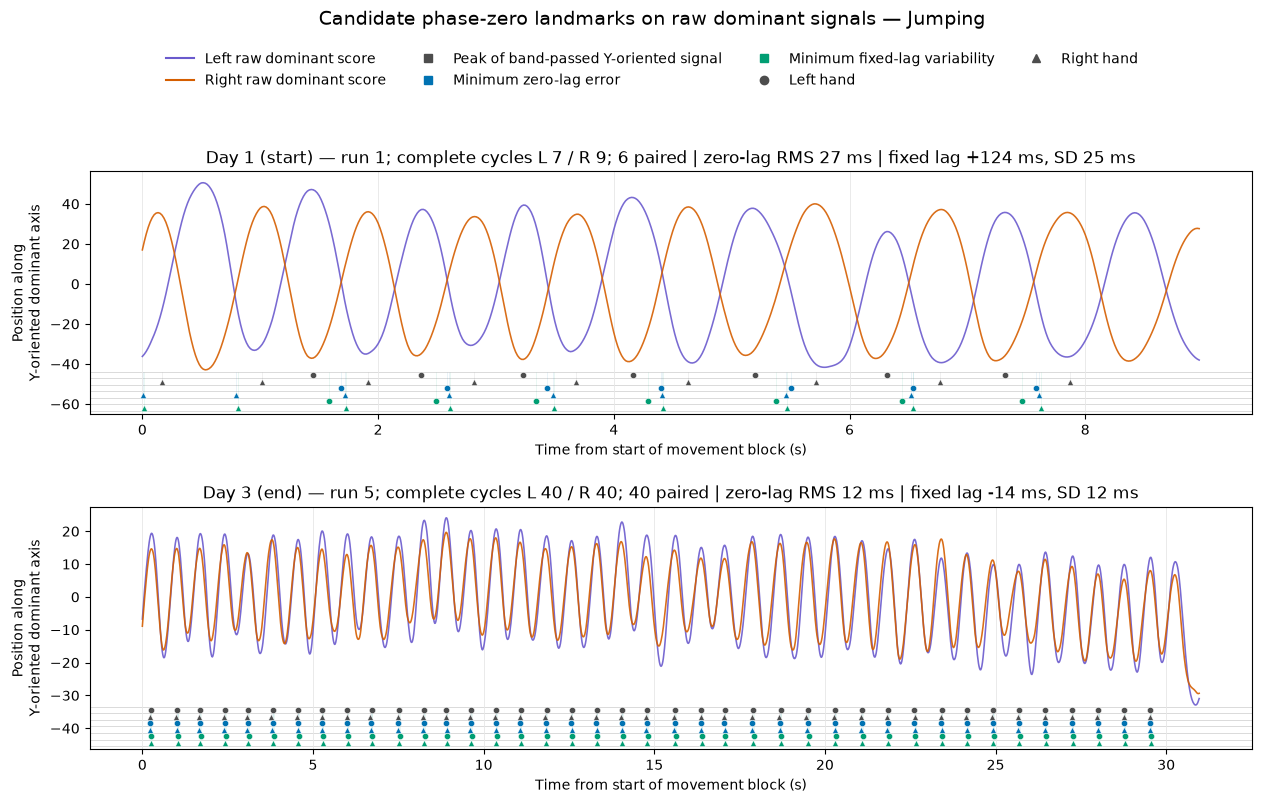

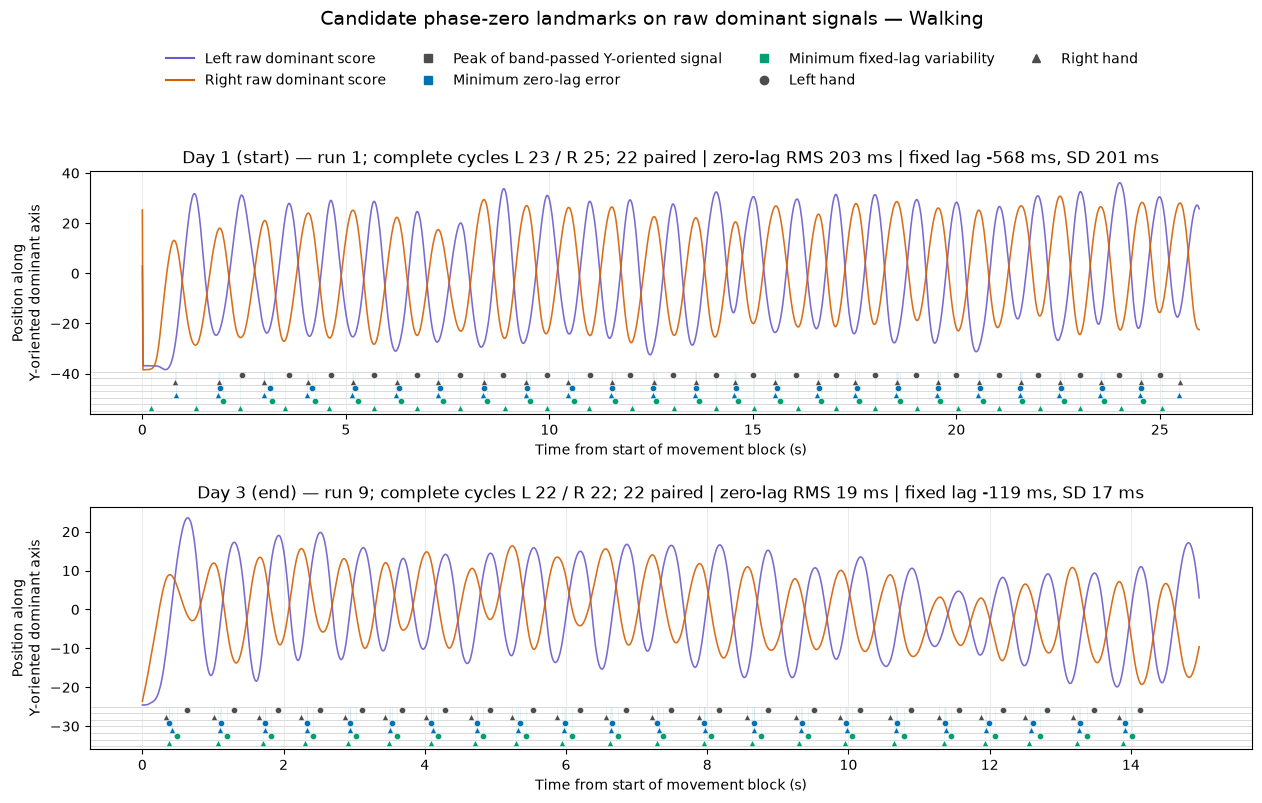

In [9]:
def representative_rows(summary):
    usable = summary[summary.fit_ok].copy()
    indices = usable.groupby(["skill", "day"])["run_duration_sec"].idxmax()
    return usable.loc[indices].sort_values(["skill", "day"]).reset_index(drop=True)


def add_event_tracks(ax, fit_pair, analysis, data_low, data_high):
    data_span = max(data_high - data_low, 1.0)
    top_rule = data_low - 0.01 * data_span
    rule_step = 0.035 * data_span
    rules = top_rule - rule_step * np.arange(7)
    track_y = (rules[:-1] + rules[1:]) / 2
    order = [
        ("peak", "l_hand"), ("peak", "r_hand"),
        ("simultaneous", "l_hand"), ("simultaneous", "r_hand"),
        ("fixed_relative", "l_hand"), ("fixed_relative", "r_hand"),
    ]
    for rule in rules:
        ax.axhline(rule, color="0.82", lw=0.55, zorder=0)
    for y, (method, hand) in zip(track_y, order):
        times = event_times(analysis["cycles"][hand], method, hand, analysis)
        ax.vlines(times, y, top_rule, color=METHOD_COLORS[method], lw=0.45, alpha=0.13)
        ax.scatter(
            times, np.full(len(times), y), s=20, marker=HAND_MARKERS[hand],
            color=METHOD_COLORS[method], edgecolor="white", linewidth=0.35, zorder=5,
        )
    expected = 3 * sum(len(analysis["cycles"][hand]) for hand in HANDS)
    actual = sum(
        len(event_times(analysis["cycles"][hand], method, hand, analysis))
        for method in METHOD_COLORS for hand in HANDS
    )
    assert actual == expected
    ax.set_ylim(rules[-1] - 0.018 * data_span, data_high + 0.06 * data_span)


representatives = representative_rows(block_summary)
display(representatives[[
    "skill", "day", "part", "movement_run_id", "run_duration_sec",
    "n_left_cycles", "n_right_cycles", "n_pairs",
    "peak_lag_sd_ms", "sim_rms_lag_ms",
    "fixed_mean_lag_ms", "fixed_lag_sd_ms",
]].round(1))

trace_handles = [
    Line2D([0], [0], color=P.HAND_COLORS["l_hand"], lw=1.5, label="Left raw dominant score"),
    Line2D([0], [0], color=P.HAND_COLORS["r_hand"], lw=1.5, label="Right raw dominant score"),
]
method_handles = [
    Line2D([0], [0], marker="s", ls="none", color=color, label=METHOD_LABELS[method])
    for method, color in METHOD_COLORS.items()
]
hand_handles = [
    Line2D([0], [0], marker=HAND_MARKERS[hand], ls="none", color="0.3", label=P.HAND_LABELS[hand])
    for hand in HANDS
]

for skill in ("climb", "jump", "walk"):
    selected = representatives[representatives.skill == skill].sort_values("day")
    fig, axes = plt.subplots(2, 1, figsize=(15, 8.5))
    for ax, row in zip(axes, selected.itertuples(index=False)):
        key = tuple(getattr(row, name) for name in KEY_COLUMNS)
        fit_pair, analysis = FITS[key], ANALYSES[key]
        values = []
        for hand in HANDS:
            fit = fit_pair[hand]
            time = fit["samples"]["time"].to_numpy(float)
            raw = fit["reference_raw"]
            color = P.HAND_COLORS[hand]
            ax.plot(time, raw, color=color, lw=1.15, alpha=0.90)
            values.append(raw)
        finite = np.concatenate(values)
        finite = finite[np.isfinite(finite)]
        data_low, data_high = float(finite.min()), float(finite.max())
        add_event_tracks(ax, fit_pair, analysis, data_low, data_high)
        fixed = analysis["methods"]["fixed_relative"]
        simultaneous = analysis["methods"]["simultaneous"]
        ax.set_title(
            f"{P.DAY_LABELS[int(row.day)]} ({P.PART_LABELS[row.part]}) — run {int(row.movement_run_id)}; "
            f"complete cycles L {int(row.n_left_cycles)} / R {int(row.n_right_cycles)}; "
            f"{int(row.n_pairs)} paired | "
            f"zero-lag RMS {1000 * np.sqrt(np.mean(simultaneous['lags'] ** 2)):.0f} ms | "
            f"fixed lag {1000 * fixed['delta']:+.0f} ms, SD {1000 * fixed['lags'].std(ddof=1):.0f} ms"
        )
        ax.set_ylabel("Position along\nY-oriented dominant axis")
        ax.set_xlabel("Time from start of movement block (s)")
        ax.grid(axis="x", color="0.9", lw=0.6)
    fig.subplots_adjust(top=0.79, hspace=0.38)
    fig.suptitle(
        f"Candidate phase-zero landmarks on raw dominant signals — {P.SKILL_LABELS[skill]}",
        fontsize=14, y=0.98,
    )
    fig.legend(
        handles=trace_handles + method_handles + hand_handles, loc="upper center",
        ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.945),
    )
    P.save_figure(fig, f"stage6_{skill}_dominant_reference_events_realtime")
    plt.show()

## Pause here

The next step should be chosen only after inspecting these real-time panels. In
particular: do the peak events land on one visually coherent oscillation per
cycle; do either fitted phase pair jump to an unintuitive part of the waveform;
does the fixed-lag method merely obtain a small SD by accepting a large delay;
and are rejected cycles concentrated in visibly weak or irregular intervals?

No objective landscapes, held-out validation, 3-D average cycles, or Bayesian
comparisons are run here yet. Those analyses should follow from what these
time-domain events actually look like rather than being added pre-emptively.